In [1]:
from fastai import *
from fastai.vision import *
from fastai.metrics import error_rate
import os
import pandas as pd
import numpy as np

In [2]:
from fastai.vision.all import *

x  = '/Users/narattamkumar/Downloads/chest_xray'
path = Path(x)
path.ls()

(#7) [Path('/Users/narattamkumar/Downloads/chest_xray/.DS_Store'),Path('/Users/narattamkumar/Downloads/chest_xray/test'),Path('/Users/narattamkumar/Downloads/chest_xray/chest_xray'),Path('/Users/narattamkumar/Downloads/chest_xray/models'),Path('/Users/narattamkumar/Downloads/chest_xray/__MACOSX'),Path('/Users/narattamkumar/Downloads/chest_xray/train'),Path('/Users/narattamkumar/Downloads/chest_xray/val')]

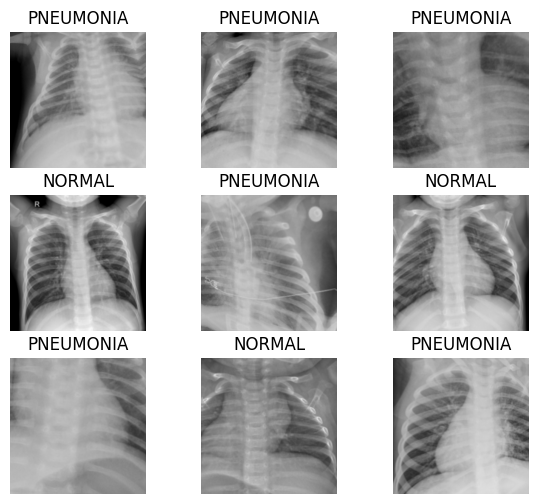

In [3]:
from fastai.vision.all import *

path = Path('/Users/narattamkumar/Downloads/chest_xray')

data = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

data.show_batch(max_n=9, figsize=(7,6))


In [4]:
dls = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    item_tfms=Resize(256),          # <-- divisible by 32
    batch_tfms=aug_transforms(size=224),  # <-- also divisible by 32
    bs=32
)


In [5]:
learn = cnn_learner(
    dls,
    resnet50,                             # or resnet34 if speed matters
    metrics=accuracy,
    model_dir=Path("models")
)

/opt/anaconda3/lib/python3.12/site-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


In [6]:
learn = cnn_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(4)


/opt/anaconda3/lib/python3.12/site-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


epoch,train_loss,valid_loss,accuracy,time


KeyboardInterrupt: 

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

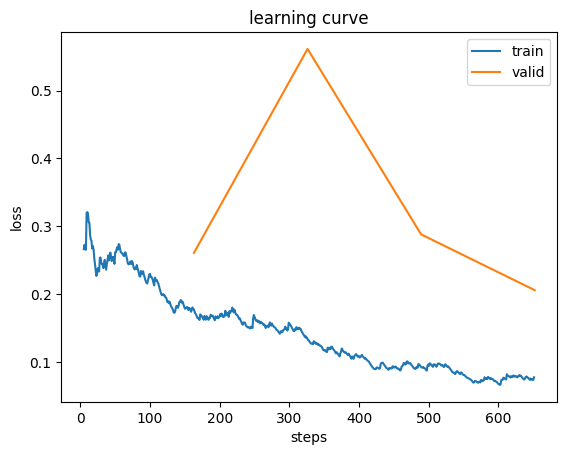

In [8]:
learn.recorder.plot_loss()


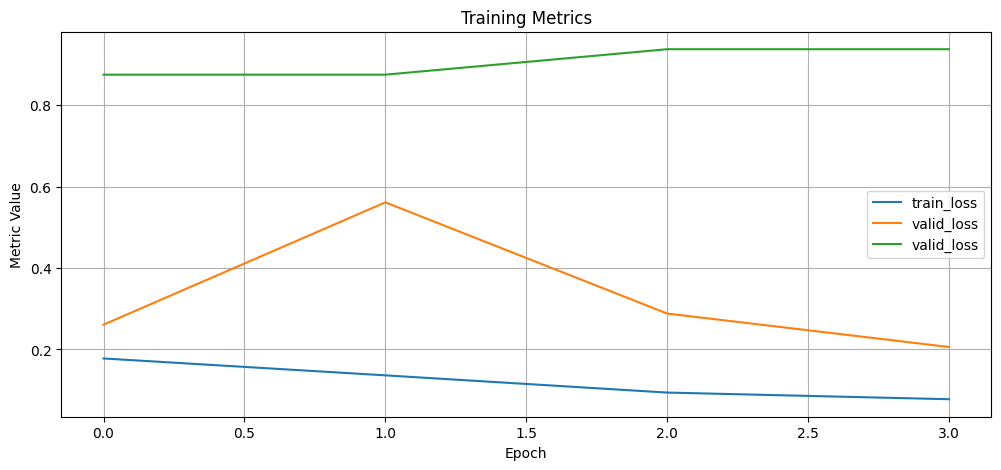

In [9]:
import matplotlib.pyplot as plt

def plot_metrics(learn):
    metrics_names = ['train_loss', 'valid_loss'] + learn.recorder.metric_names[2:-1]
    values = list(zip(*learn.recorder.values))
    epochs = range(len(learn.recorder.values))

    plt.figure(figsize=(12,5))
    
    for i, (metric_name, val) in enumerate(zip(metrics_names, values)):
        plt.plot(epochs, val, label=metric_name)
    
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('Training Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metrics(learn)


AttributeError: 'Sequential' object has no attribute 'plot_lr_find'

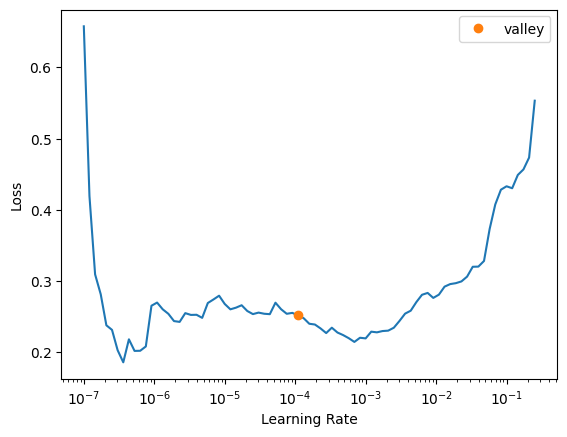

In [11]:
learn.unfreeze()
learn.lr_find()
learn.plot_lr_find()     # or plot_lr_find(learn)

learn.fit_one_cycle(10, slice(1e-5, 1e-3))

learn.plot_loss()        # shows loss curves


In [12]:
lr1 = 1e-3
lr2 = 1e-1
learn.fit_one_cycle(4,slice(lr1,lr2))

# lr1 = 1e-3
lr = 1e-1
learn.fit_one_cycle(20,slice(lr))

learn.unfreeze()
learn.lr_find()
learn.recorder.plot()
learn.fit_one_cycle(10,slice(1e-4,1e-3))

learn.recorder.plot_losses()

epoch,train_loss,valid_loss,accuracy,time
0,0.775833,1.206330,0.687500,01:56
1,0.601319,0.315882,0.812500,01:54
2,0.285525,0.405952,0.812500,01:53
3,0.122299,0.206965,0.937500,01:53


epoch,train_loss,valid_loss,accuracy,time


KeyboardInterrupt: 

In [14]:
learn.fit_one_cycle(5,slice(lr))

epoch,train_loss,valid_loss,accuracy,time
0,0.707520,3.414290,0.562500,01:55
1,0.565971,0.817965,0.625000,01:54
2,0.253999,1.965788,0.562500,01:55
3,0.232195,0.503922,0.812500,01:53
4,0.187303,0.601870,0.750000,02:02


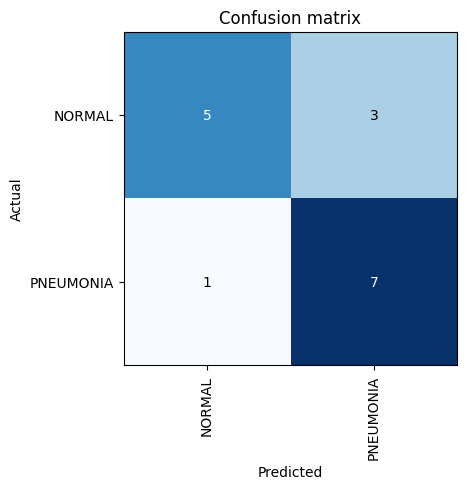

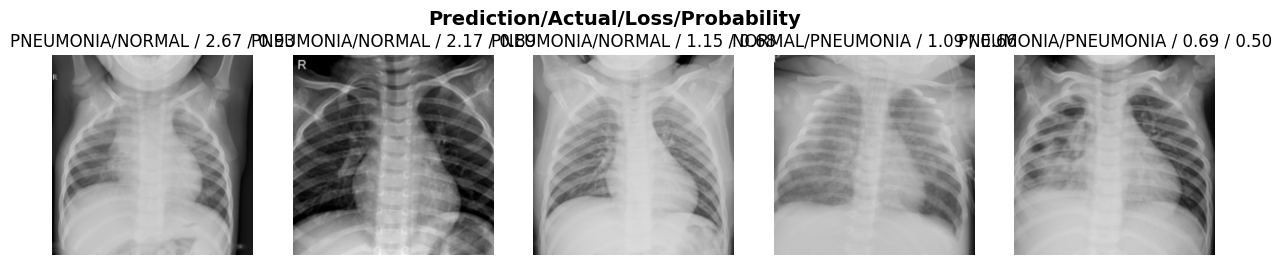

In [17]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(5, nrows=1)


In [18]:
learn = cnn_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(4)


/opt/anaconda3/lib/python3.12/site-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


epoch,train_loss,valid_loss,accuracy,time
0,0.386613,0.517657,0.875000,01:50


epoch,train_loss,valid_loss,accuracy,time
0,0.206514,0.728174,0.875000,02:17
1,0.132073,0.762943,0.875000,02:15
2,0.113400,0.111741,0.937500,02:19
3,0.067428,0.224746,0.937500,18:31


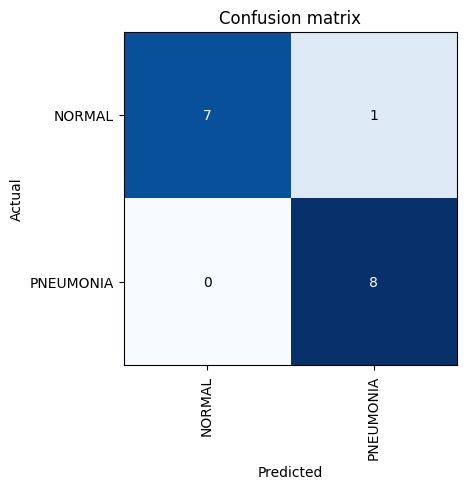

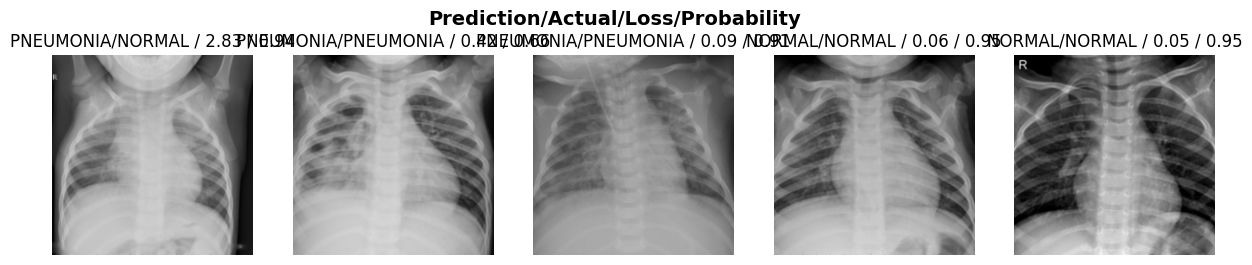

In [19]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(5, nrows=1)